In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from matplotlib.ticker import FuncFormatter, ScalarFormatter

In [2]:
# Sample 5 equidistant colours from a perceptually uniform colormap (e.g., 'viridis')
import matplotlib

cmap = matplotlib.cm.get_cmap('magma')
colors = [cmap(i) for i in np.linspace(0, 1, 6)]
print("Sampled colors from 'viridis':", colors)
light_green = matplotlib.colors.to_rgba("green")
print("Float RGBA for 'lightgreen':", light_green)
colors[0] = light_green  # Replace the first color with light green
color_idxs = [0, 1, 2,3, 4] # 0 
colors = [colors[i] for i in color_idxs]

Sampled colors from 'viridis': [(np.float64(0.001462), np.float64(0.000466), np.float64(0.013866), np.float64(1.0)), (np.float64(0.232077), np.float64(0.059889), np.float64(0.437695), np.float64(1.0)), (np.float64(0.550287), np.float64(0.161158), np.float64(0.505719), np.float64(1.0)), (np.float64(0.868793), np.float64(0.287728), np.float64(0.409303), np.float64(1.0)), (np.float64(0.994738), np.float64(0.62435), np.float64(0.427397), np.float64(1.0)), (np.float64(0.987053), np.float64(0.991438), np.float64(0.749504), np.float64(1.0))]
Float RGBA for 'lightgreen': (0.0, 0.5019607843137255, 0.0, 1.0)


/tmp/ipykernel_103028/1283779246.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('magma')


In [ ]:
# --- 1. Configuration ---

# The root directory to search for log files.
# All subdirectories will be scanned.
TITLE = 'Partial Observations'
KEYWORD = 'partial'
ENV = "cheetah"
ENV_NAME = 'cheetah_run'
SIM = 'dmc'
ROOT_DIR = f'data/{SIM}/{ENV}/{KEYWORD}/'

# Optional: A dictionary to rename the methods found from directory names.
# For example, if logs are in a folder named 'v1', you can map it to 'My Method v1'.
METHOD_RENAMING = {
    'vanilla': 'Vanilla DreamerV3',
    'rnd': "RND",
    #
}

# The maximum step to include in the plot. Data beyond this will be ignored.
if "vision" in KEYWORD:
    MAX_STEP = 1000000
else:
    MAX_STEP = 500000

# The number of bins to group data into for plotting.
NUM_BINS = 25

In [4]:
import json

def convert_json_to_jsonl(input_path, output_path):
    """
    Loads a JSON file with format [[A1, B1, C1], ...] and writes a JSONL file with
    {"time":A1, "step":B1, "episode/score":C1} per line.
    """
    with open(input_path, 'r') as f:
        data = json.load(f)
    with open(output_path, 'w') as f:
        # First write opening bracket for JSONL format
        for row in data:
            obj = {"time": row[0], "step": row[1], "epstats/score": row[2]}
            f.write(json.dumps(obj) + '\n')

# Example usage:
os.makedirs(f'data/{SIM}/{ENV}/{KEYWORD}/rnd', exist_ok=True)
filenames = os.listdir(f'data/{SIM}/{ENV}/{KEYWORD}/rnd-0')
for filename in filenames:
    seed = filename.split('_')[-1].split('.')[0]
    if filename.endswith('.json'):
        input_path = os.path.join(f'data/{SIM}/{ENV}/{KEYWORD}/rnd-0', filename)
        output_path = os.path.join(f'data/{SIM}/{ENV}/{KEYWORD}/rnd', f"{seed}_scores_all.jsonl")
        convert_json_to_jsonl(input_path, output_path)

FileNotFoundError: [Errno 2] No such file or directory: 'data/dmc/cheetah/partial_obs/rnd-0'

In [4]:
# --- 2. Find and Load Data ---

def load_data_from_dir(root_dir, max_step, renaming_dict):
    """
    Recursively finds score files, loads them into a DataFrame,
    and uses parent directory names as method labels.
    """
    all_data = []
    # Regex to find files like s0_scores.jsonl, s1_scores_all.jsonl, etc.
    file_pattern = re.compile(r's(\d+)_scores.*\.jsonl')

    print(f"Searching for log files in: {root_dir}")

    for root, _, files in os.walk(root_dir):
        print(files)
        for filename in files:
            match = file_pattern.match(filename)
            if match:
                seed_num = match.group(1)
                # The method name is the name of the directory containing the file.
                method_name = os.path.basename(root)
                
                # Rename the method if a rule exists in the dictionary.
                display_name = renaming_dict.get(method_name, method_name)
                
                file_path = os.path.join(root, filename)
                print(f"  - Found: {file_path} (Method: '{display_name}', Seed: {seed_num})")
                
                try:
                    with open(file_path, 'r') as f:
                        for line in f:
                            entry = json.loads(line)
                            step = entry.get("step")
                            
                            # Filter out steps beyond the maximum limit.
                            if step is not None and step <= max_step:
                                # Handle different possible keys for the score
                                score = entry.get('score') or entry.get('epstats/score')
                                if score is not None:
                                    all_data.append({
                                        "step": step,
                                        "score": score,
                                        "method": display_name,
                                        "seed": f"{display_name}_seed_{seed_num}"
                                    })
                except Exception as e:
                    print(f"    Warning: Could not process file {file_path}. Error: {e}")
    
    if not all_data:
        return pd.DataFrame()
        
    return pd.DataFrame(all_data)

# Load all data according to the configuration.
df = load_data_from_dir(ROOT_DIR, MAX_STEP, METHOD_RENAMING)

if df.empty:
    print("\nNo data loaded. Please check the ROOT_DIR and file names.")
else:
    print("\nData loading complete.")

Searching for log files in: data/dmc/cheetah/partial_obs/
[]
[]

No data loaded. Please check the ROOT_DIR and file names.


In [5]:
# --- 3. Create Step Bins for Plotting ---

if not df.empty:
    # Use the actual max step from the filtered data for accurate binning.
    max_step_in_data = df['step'].max()
    bins = np.linspace(0, max_step_in_data, NUM_BINS)
    df['step_bin'] = pd.cut(df['step'], bins=bins, include_lowest=True)
    df['step_bin_mid'] = df['step_bin'].apply(lambda x: x.mid)
    print("Data binned successfully.")
    display(df.head())

In [6]:
df["method"].unique()

KeyError: 'method'

In [ ]:
df["method"] = df["method"].replace('Vanilla DreamerV3', '0.0')
df["method"] = df["method"].replace('RND', '-1.0')
df["method_str"] = df["method"].astype(str)

In [ ]:
df["method"] = df["method"].astype(float)

In [ ]:
# lengend_dict = {'0.0025':"k=25e-4", '0.1':"k=1e-1", '0.5':"k=5e-2", '0.05':"k=5e-2", 'Vanilla DreamerV3':"k=0"}
legend_dict = {"-1.0":"RND", '0.025':"k=0.025", '0.0025':"k=0.0025", '0.1':"k=0.1", '0.5':"k=0.5", '0.05':"k=0.05", "0.075":"k=0.075", '0.0':"k=0"}

Legend handles and labels: [<matplotlib.lines.Line2D object at 0x7f5f3b629090>, <matplotlib.lines.Line2D object at 0x7f5f3b6293c0>, <matplotlib.lines.Line2D object at 0x7f5f3b629690>, <matplotlib.lines.Line2D object at 0x7f5f3b629960>, <matplotlib.lines.Line2D object at 0x7f5f3b629c30>] ['-1.0', '0.0', '0.025', '0.05', '0.1']


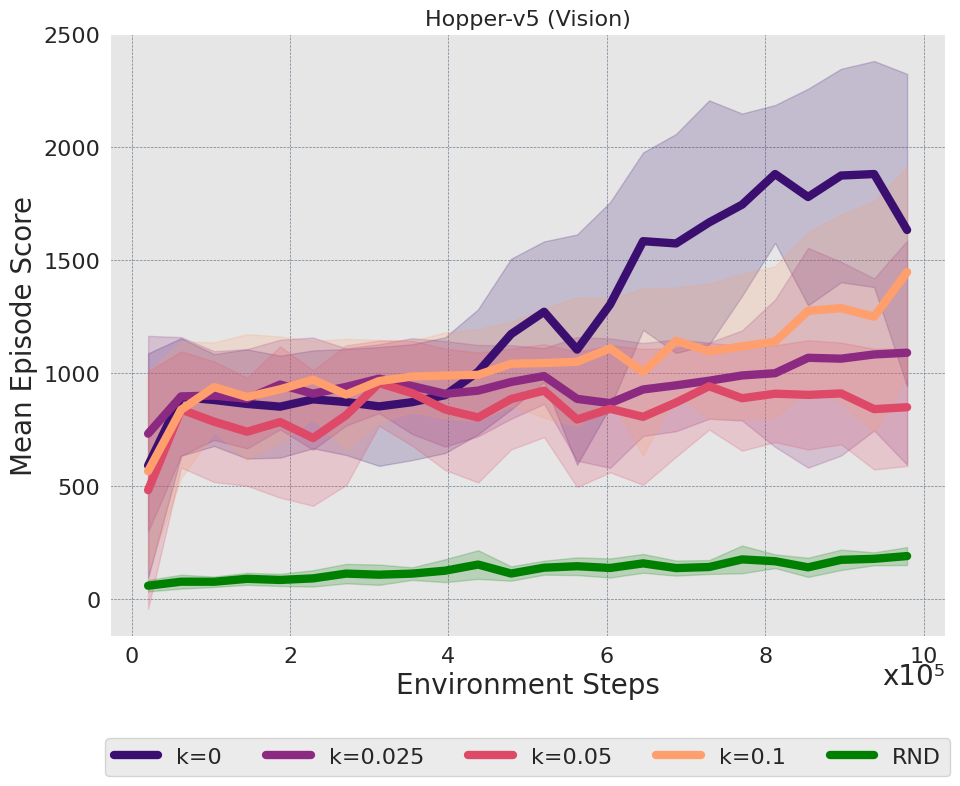

In [ ]:
# --- 4. Plot with Seaborn ---

from matplotlib.ticker import FuncFormatter

if not df.empty:
    plt.figure(figsize=(10, 8))

    sns.set_style("darkgrid", {"axes.facecolor": ".9", 
                               'grid.linestyle': '--', 
                               'grid.color': 'slategrey'})
    
    # Seaborn groups by 'step_bin' and 'method' (from `hue`), 
    # calculates the mean score, and shows the standard deviation.
    # for idx, method in enumerate(df['method'].unique()):
    #     method_data = df[df['method'] == method]
    ax = sns.lineplot(
        data=df, 
        x='step_bin_mid', 
        y='score', 
        hue='method',      # Creates separate lines for each method
        errorbar='sd',     # 'sd' for standard deviation uncertainty band
        # marker='',
        markersize=3,
        linewidth=6,
        palette=colors,    # Use the sampled colors
    )

    # Customize the x-axis to show 1, 2, 3, ... and label as x10^5
    def format_func(value, tick_number):
        return f"{int(value / 1e5)}"

    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_func))
    # Remove x10⁵ from here

    # Add x10^5 at the end of the axis
    plt.text(
        x=plt.gca().get_xlim()[1],  # Get the maximum x-axis value
        y=plt.gca().get_ylim()[0] - 0.08 * (plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]),  # Slightly below the x-axis
        s="x10⁵",
        fontsize=20,
        ha='right'
    )

    handles, labels = plt.gca().get_legend_handles_labels()
    print("Legend handles and labels:", handles, labels)
    order = [1, 2, 3, 4,0]
    plt.legend([handles[idx] for idx in order],[legend_dict[labels[idx]] for idx in order], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=5, fontsize=16)


    plt.title(f"{ENV_NAME} ({TITLE})", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # plt.yticks(fontsize=16, fontweight='bold')
    plt.xlabel('Environment Steps', fontsize=20)  # Add
    plt.ylabel('Mean Episode Score', fontsize=20)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # plt.legend(title='', fontsize=10)
    plt.tight_layout()
    # plt.savefig(f'pdfs_new/{SIM}_{ENV}_{KEYWORD}.pdf', format="pdf")
    # plt.savefig(f'pdfs/{ENV}_ctrl_10x.pdf', format="pdf")
    plt.show()

In [ ]:
labels

['0.0', '0.025', '0.05']

In [ ]:
labels

['0.0', '0.0025', '0.05', '0.1', '0.5']

In [ ]:
# Float RGBA values for a light green color
import matplotlib

